# Analysis Notebook — Conversational Clustering on UCDP GEDEvent 25.1

**Pre-specified analysis plan:** `docs/study_design.md §8`  
**Quality spec:** `docs/quality_spec.md`  
**Input:** `runs/run_log.jsonl` (append-only experiment log)  

**Run `scripts/check_integrity.py` before opening this notebook.**  
All analyses are pre-specified. Any analysis not listed in `study_design.md §8` must be labelled exploratory and post-hoc.

---

### Hypotheses tested here
- **H1 (confirmatory):** Conversational refinement improves Silhouette score vs baseline (Condition B/F2 vs A/F2, Wilcoxon signed-rank, p < 0.05, bootstrap CI excludes 0)
- **H2 (exploratory):** Improvement is larger under F2 than F1
- **H3 (confirmatory):** Oracle–human Spearman ρ > 0.7 with bootstrap CI lower bound > 0.5

### What this notebook does NOT do
- Does not re-draw the sample or re-run clustering
- Does not test metrics not listed in `docs/quality_spec.md §8`
- Does not interpret refused runs as complete runs

In [1]:
import json
import warnings
from pathlib import Path

import jsonlines
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

LOG_PATH = Path('../runs/run_log.jsonl')
assert LOG_PATH.exists(), f'Log file not found: {LOG_PATH}. Run check_integrity.py first.'
print(f'Log file found: {LOG_PATH}')

Log file found: ..\runs\run_log.jsonl


## 1. Load and validate the log

In [2]:
records = []
with jsonlines.open(LOG_PATH) as reader:
    for rec in reader:
        records.append(rec)

df_log = pd.DataFrame(records)
print(f'Total records in log: {len(df_log)}')
print(f'Status breakdown:')
print(df_log['status'].value_counts().to_string())

Total records in log: 180
Status breakdown:
status
complete    180


In [3]:
# Keep only complete runs for analysis
# Refused and error runs are reported as data loss — never silently dropped
refused = df_log[df_log['status'] == 'refused']
errors  = df_log[df_log['status'] == 'error']

if len(refused) > 0:
    print(f'⚠ DATA LOSS: {len(refused)} refused runs (Claude safety filter).')
    print('These must be reported in the paper limitations section.')
    print(refused[['run_id', 'condition', 'feature_set', 'seed']].to_string())

if len(errors) > 0:
    print(f'⚠ {len(errors)} error runs — investigate before proceeding.')
    print(errors[['run_id', 'condition', 'feature_set', 'seed']].to_string())

df = df_log[df_log['status'] == 'complete'].copy()
df['silhouette_final'] = pd.to_numeric(df['silhouette_final'])
df['davies_bouldin_final'] = pd.to_numeric(df['davies_bouldin_final'])
print(f'\nComplete runs available for analysis: {len(df)}')
print(df.groupby(['condition', 'feature_set']).size().rename('n_runs').to_string())


Complete runs available for analysis: 180
condition  feature_set
A          F1             30
           F2             30
B          F1             30
           F2             30
C          F1             30
           F2             30


## 2. Descriptive statistics (study_design §8, step 1)

In [4]:
desc = (
    df.groupby(['condition', 'feature_set'])['silhouette_final']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .round(4)
)
desc.columns = ['mean', 'std', 'min', 'max', 'n']
print('Silhouette score — descriptive statistics')
print('=' * 55)
print(desc.to_string())

Silhouette score — descriptive statistics
                         mean     std     min     max   n
condition feature_set                                    
A         F1           0.9048  0.0007  0.9044  0.9061  30
          F2           0.8936  0.0006  0.8933  0.8950  30
B         F1           0.8512  0.1040  0.5873  0.9462  30
          F2           0.8514  0.0979  0.6449  1.0000  30
C         F1           0.8743  0.1669  0.0000  0.9470  30
          F2           0.8630  0.0533  0.7000  0.9103  30


In [5]:
desc_db = (
    df.groupby(['condition', 'feature_set'])['davies_bouldin_final']
    .agg(['mean', 'std', 'min', 'max'])
    .round(4)
)
desc_db.columns = ['mean', 'std', 'min', 'max']
print('Davies-Bouldin index — descriptive statistics (lower = better)')
print('=' * 55)
print(desc_db.to_string())

Davies-Bouldin index — descriptive statistics (lower = better)
                         mean     std     min     max
condition feature_set                                
A         F1           1.0724  0.0798  0.9310  1.1183
          F2           0.9974  0.0965  0.9550  1.2096
B         F1           0.9683  0.1640  0.6024  1.1500
          F2           0.8054  0.2621  0.0000  1.2096
C         F1              inf     NaN  0.5138     inf
          F2           0.8880  0.1913  0.5830  1.1718


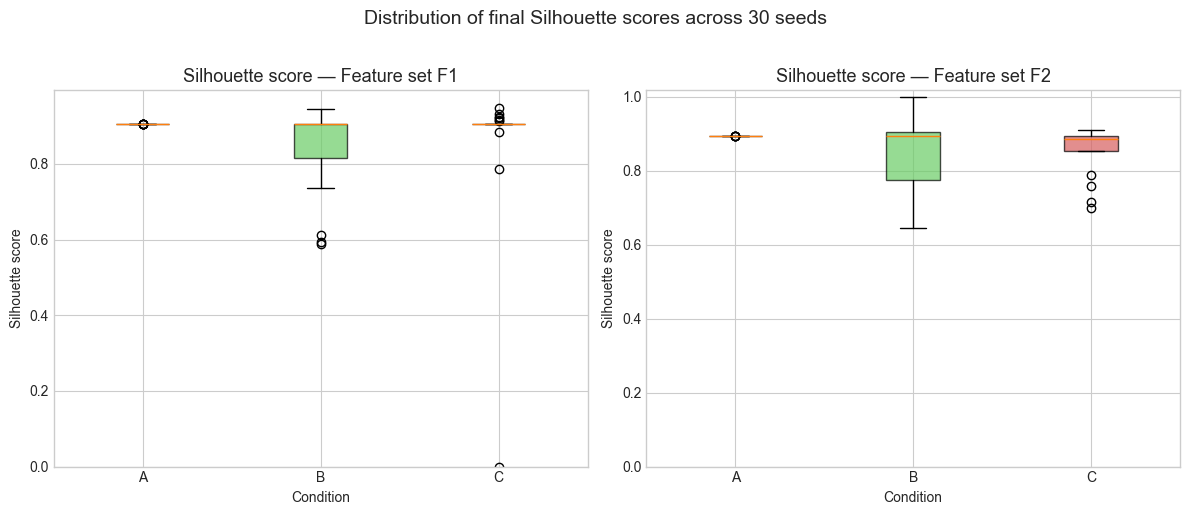

Saved: runs/fig_silhouette_boxplot.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, fs in zip(axes, ['F1', 'F2']):
    subset = df[df['feature_set'] == fs]
    conditions_present = sorted(subset['condition'].unique())
    if not conditions_present:
        ax.text(0.5, 0.5, f'No data yet for {fs}',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'Silhouette score — Feature set {fs}', fontsize=13)
        continue
    data_to_plot = [subset[subset['condition'] == c]['silhouette_final'].values
                    for c in conditions_present]
    bp = ax.boxplot(data_to_plot, tick_labels=conditions_present, patch_artist=True)
    colours = ['#4878CF', '#6ACC65', '#D65F5F']
    for patch, colour in zip(bp['boxes'], colours[:len(conditions_present)]):
        patch.set_facecolor(colour)
        patch.set_alpha(0.7)
    ax.set_title(f'Silhouette score — Feature set {fs}', fontsize=13)
    ax.set_xlabel('Condition')
    ax.set_ylabel('Silhouette score')
    ax.set_ylim(bottom=0)

plt.suptitle('Distribution of final Silhouette scores across 30 seeds', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../runs/fig_silhouette_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: runs/fig_silhouette_boxplot.png')

## 3. H1 — Wilcoxon signed-rank test (study_design §8, step 2)

**Test:** Condition B/F2 vs Condition A/F2, paired by seed.  
**Decision rule:** One-sided Wilcoxon p < 0.05 AND bootstrap 95% CI on median improvement excludes zero.

In [7]:
def get_paired(cond_1, cond_2, feature_set, metric='silhouette_final'):
    """Return paired arrays (a, b) matched by seed for two conditions."""
    a = df[(df['condition'] == cond_1) & (df['feature_set'] == feature_set)]
    b = df[(df['condition'] == cond_2) & (df['feature_set'] == feature_set)]
    merged = a[['seed', metric]].merge(b[['seed', metric]], on='seed', suffixes=('_a', '_b'))
    return merged[f'{metric}_a'].values, merged[f'{metric}_b'].values, merged['seed'].values

def bootstrap_ci_median_diff(a, b, n_boot=10_000, rng_seed=42):
    """Bootstrap 95% CI on median(b - a)."""
    rng = np.random.default_rng(rng_seed)
    diffs = b - a
    boot_medians = [
        np.median(rng.choice(diffs, size=len(diffs), replace=True))
        for _ in range(n_boot)
    ]
    return np.percentile(boot_medians, [2.5, 97.5])

def matched_pairs_r(stat, n):
    """Effect size r from Wilcoxon W statistic."""
    z = (stat - n*(n+1)/4) / np.sqrt(n*(n+1)*(2*n+1)/24)
    return abs(z) / np.sqrt(n)

# ── H1 test ────────────────────────────────────────────────────────────────
h1_conditions = [('A', 'B'), ('A', 'C')]  # baseline vs each treatment

for cond_baseline, cond_treatment in h1_conditions:
    try:
        sil_a, sil_b, seeds = get_paired(cond_baseline, cond_treatment, 'F2')
    except Exception:
        print(f'Condition {cond_treatment}/F2 not yet available — skipping.')
        continue

    if len(sil_a) < 2:
        print(f'Not enough paired observations for {cond_baseline} vs {cond_treatment}.')
        continue

    diffs = sil_b - sil_a
    stat, p_val = stats.wilcoxon(sil_b, sil_a, alternative='greater')
    ci_low, ci_high = bootstrap_ci_median_diff(sil_a, sil_b)
    r = matched_pairs_r(stat, len(diffs))

    print(f'\n── H1: Condition {cond_treatment}/F2 vs {cond_baseline}/F2 ──')
    print(f'  n paired seeds:       {len(diffs)}')
    print(f'  Median improvement:   {np.median(diffs):+.4f}')
    print(f'  Bootstrap 95% CI:     [{ci_low:.4f}, {ci_high:.4f}]')
    print(f'  Wilcoxon W:           {stat:.1f}')
    print(f'  p-value (one-sided):  {p_val:.4f}')
    print(f'  Effect size r:        {r:.3f}')

    # Decision rule
    confirmatory = (p_val < 0.05) and (ci_low > 0)
    if confirmatory:
        print(f'  ✓ H1 SUPPORTED: p < 0.05 and CI excludes zero.')
    elif p_val < 0.05:
        print(f'  ~ TRENDING: p < 0.05 but CI includes zero — inconclusive.')
    else:
        print(f'  ✗ H1 NOT SUPPORTED: p = {p_val:.4f}')


── H1: Condition B/F2 vs A/F2 ──
  n paired seeds:       30
  Median improvement:   -0.0003
  Bootstrap 95% CI:     [-0.0632, 0.0015]
  Wilcoxon W:           141.0
  p-value (one-sided):  0.9210
  Effect size r:        0.344
  ✗ H1 NOT SUPPORTED: p = 0.9210

── H1: Condition C/F2 vs A/F2 ──
  n paired seeds:       30
  Median improvement:   -0.0065
  Bootstrap 95% CI:     [-0.0307, -0.0014]
  Wilcoxon W:           79.0
  p-value (one-sided):  0.9995
  Effect size r:        0.576
  ✗ H1 NOT SUPPORTED: p = 0.9995


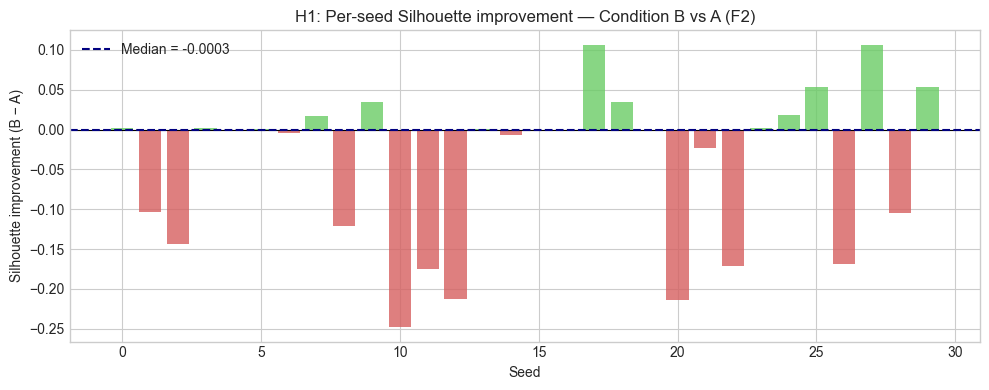

Saved: runs/fig_h1_improvement.png


In [8]:
# Per-seed improvement plot for H1
try:
    sil_a, sil_b, seeds = get_paired('A', 'B', 'F2')
    diffs = sil_b - sil_a

    fig, ax = plt.subplots(figsize=(10, 4))
    colours = ['#6ACC65' if d > 0 else '#D65F5F' for d in diffs]
    ax.bar(seeds, diffs, color=colours, alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axhline(np.median(diffs), color='navy', linewidth=1.5,
               linestyle='--', label=f'Median = {np.median(diffs):+.4f}')
    ax.set_xlabel('Seed')
    ax.set_ylabel('Silhouette improvement (B − A)')
    ax.set_title('H1: Per-seed Silhouette improvement — Condition B vs A (F2)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../runs/fig_h1_improvement.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: runs/fig_h1_improvement.png')
except Exception as e:
    print(f'Condition B not yet available for H1 plot: {e}')

## 4. H2 — Exploratory: F1 vs F2 improvement (study_design §8, step 3)

**Test:** Is the B−A improvement larger under F2 than F1?  
Mann-Whitney U on per-seed improvement scores.  
**Labelled exploratory — no multiple-comparison correction.**

In [9]:
try:
    sil_a_f1, sil_b_f1, _ = get_paired('A', 'B', 'F1')
    sil_a_f2, sil_b_f2, _ = get_paired('A', 'B', 'F2')

    improvement_f1 = sil_b_f1 - sil_a_f1
    improvement_f2 = sil_b_f2 - sil_a_f2

    u_stat, p_u = stats.mannwhitneyu(improvement_f2, improvement_f1, alternative='greater')

    print('── H2 (EXPLORATORY): F2 improvement vs F1 improvement ──')
    print(f'  Median improvement F1: {np.median(improvement_f1):+.4f}')
    print(f'  Median improvement F2: {np.median(improvement_f2):+.4f}')
    print(f'  Mann-Whitney U:        {u_stat:.1f}')
    print(f'  p-value (one-sided):   {p_u:.4f}')
    print('  ⚠ Exploratory result — no multiple-comparison correction applied.')

    if p_u < 0.05:
        print('  ~ F2 improvement appears larger than F1 improvement.')
    else:
        print('  ~ No clear difference in improvement magnitude between F1 and F2.')
except Exception as e:
    print(f'Condition B not yet available for H2: {e}')

── H2 (EXPLORATORY): F2 improvement vs F1 improvement ──
  Median improvement F1: +0.0000
  Median improvement F2: -0.0003
  Mann-Whitney U:        476.0
  p-value (one-sided):   0.3522
  ⚠ Exploratory result — no multiple-comparison correction applied.
  ~ No clear difference in improvement magnitude between F1 and F2.


## 5. Robustness check — Davies-Bouldin (study_design §8, step 5)

In [10]:
try:
    db_a, db_b, _ = get_paired('A', 'B', 'F2', metric='davies_bouldin_final')
    # For DB: lower is better, so improvement = a - b (treatment should be lower)
    stat_db, p_db = stats.wilcoxon(db_a, db_b, alternative='greater')  # a > b = improvement
    ci_db = bootstrap_ci_median_diff(db_b, db_a)  # CI on a - b

    print('── Robustness check: Davies-Bouldin (lower = better) ──')
    print(f'  Median DB reduction (A − B): {np.median(db_a - db_b):+.4f}')
    print(f'  Bootstrap 95% CI:            [{ci_db[0]:.4f}, {ci_db[1]:.4f}]')
    print(f'  Wilcoxon p (one-sided):      {p_db:.4f}')

    if p_db < 0.05:
        print('  ✓ DB result consistent with Silhouette (both support H1).')
    else:
        print('  ⚠ DB result diverges from Silhouette — discuss in paper.')
except Exception as e:
    print(f'Condition B not yet available for DB robustness check: {e}')

── Robustness check: Davies-Bouldin (lower = better) ──
  Median DB reduction (A − B): +0.1378
  Bootstrap 95% CI:            [0.0400, 0.2613]
  Wilcoxon p (one-sided):      0.0000
  ✓ DB result consistent with Silhouette (both support H1).


## 6. Per-turn trajectory (exploratory, study_design §8, step 6)

Saved: runs/fig_turn_trajectory.png


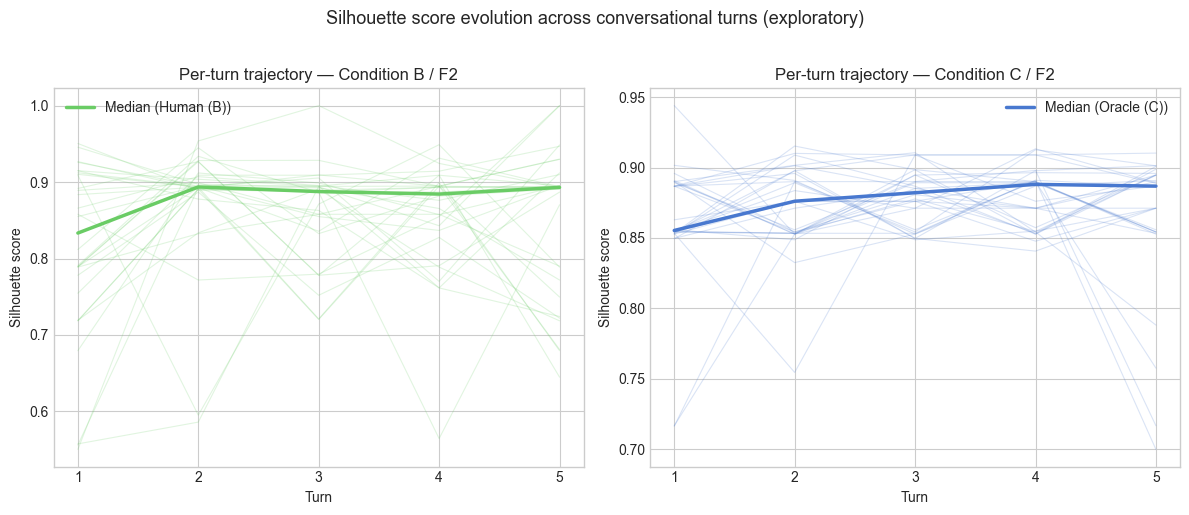

In [11]:
def extract_trajectories(condition, feature_set):
    """Extract per-turn silhouette scores for all seeds in a condition."""
    subset = df[(df['condition'] == condition) & (df['feature_set'] == feature_set)]
    rows = []
    for _, rec in subset.iterrows():
        turns = rec.get('turns', [])
        if not turns:
            continue
        for t in turns:
            rows.append({
                'seed':      rec['seed'],
                'turn':      t['turn'],
                'silhouette': t['silhouette'],
            })
    return pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plotted_any = False

for ax, (cond, label, colour) in zip(axes, [('B', 'Human (B)', '#6ACC65'), ('C', 'Oracle (C)', '#4878CF')]):
    traj = extract_trajectories(cond, 'F2')
    if traj.empty:
        ax.text(0.5, 0.5, f'Condition {cond} not yet run',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'Turn trajectory — Condition {cond} / F2')
        continue
    plotted_any = True
    # Plot individual seed trajectories faintly
    for seed, grp in traj.groupby('seed'):
        ax.plot(grp['turn'], grp['silhouette'], color=colour, alpha=0.2, linewidth=0.8)
    # Plot median trajectory boldly
    median_traj = traj.groupby('turn')['silhouette'].median()
    ax.plot(median_traj.index, median_traj.values, color=colour,
            linewidth=2.5, label=f'Median ({label})')
    ax.set_xlabel('Turn')
    ax.set_ylabel('Silhouette score')
    ax.set_title(f'Per-turn trajectory — Condition {cond} / F2')
    ax.set_xticks(range(1, 6))
    ax.legend()

plt.suptitle('Silhouette score evolution across conversational turns (exploratory)', fontsize=13, y=1.02)
plt.tight_layout()
if plotted_any:
    plt.savefig('../runs/fig_turn_trajectory.png', dpi=150, bbox_inches='tight')
    print('Saved: runs/fig_turn_trajectory.png')
plt.show()

## 7. H3 — Oracle–human agreement (study_design §8, step 4)

**Input:** manually collected human ratings CSV and oracle ratings.  
**Decision rule:** Spearman ρ > 0.7 AND bootstrap CI lower bound > 0.5. Cohen's κ ≥ 0.40 required.

This section expects a file `runs/human_ratings.csv` with columns:  
`pair_id, rater_1, rater_2, ..., rater_N`  (values: 'A' or 'B')  
and a file `runs/oracle_ratings.csv` with columns:  
`pair_id, oracle_choice`  (values: 'A' or 'B')

In [12]:
import krippendorff

human_path  = Path('../runs/human_ratings.csv')
oracle_path = Path('../runs/oracle_ratings.csv')

if not human_path.exists() or not oracle_path.exists():
    print('H3 inputs not yet available.')
    print(f'  Expected: {human_path}')
    print(f'  Expected: {oracle_path}')
    print('Run human rating session and oracle evaluation first.')
else:
    # ── Load ratings ─────────────────────────────────────────────────────
    human_df  = pd.read_csv(human_path)
    oracle_df = pd.read_csv(oracle_path)

    rater_cols = [c for c in human_df.columns if c != 'pair_id']
    print(f'Human raters: {len(rater_cols)} ({rater_cols})')
    print(f'Pairs: {len(human_df)}')

    # ── Inter-rater reliability (Krippendorff α) ─────────────────────────
    # Encode A=0, B=1 for krippendorff
    rating_matrix = human_df[rater_cols].replace({'A': 0, 'B': 1}).values.T.tolist()
    alpha = krippendorff.alpha(reliability_data=rating_matrix, level_of_measurement='nominal')

    print(f'\n── Inter-rater reliability ──')
    print(f"  Krippendorff's α: {alpha:.3f}")
    if alpha < 0.20:
        print('  ✗ α < 0.20: Human data unreliable. H3 reported as infeasible.')
    elif alpha < 0.40:
        print('  ⚠ α < 0.40: H3 proceeds with prominent reliability caveat.')
    else:
        print('  ✓ α ≥ 0.40: Acceptable reliability for H3.')

    # ── Majority vote ─────────────────────────────────────────────────────
    def majority_vote(row):
        vals = row[rater_cols].dropna().values
        n_a = (vals == 'A').sum()
        n_b = (vals == 'B').sum()
        if n_a > n_b: return 'A'
        if n_b > n_a: return 'B'
        return 'TIE'

    human_df['majority'] = human_df.apply(majority_vote, axis=1)
    n_ties = (human_df['majority'] == 'TIE').sum()
    print(f'\n  Tied pairs (excluded from ρ): {n_ties}')

    # ── Merge with oracle ─────────────────────────────────────────────────
    merged = human_df[['pair_id', 'majority']].merge(oracle_df, on='pair_id')
    merged = merged[merged['majority'] != 'TIE'].copy()

    human_bin  = (merged['majority'] == 'B').astype(int).values
    oracle_bin = (merged['oracle_choice'] == 'B').astype(int).values
    n_pairs = len(merged)

    # ── Spearman ρ ────────────────────────────────────────────────────────
    rho, p_rho = stats.spearmanr(human_bin, oracle_bin)

    rng = np.random.default_rng(42)
    boot_rhos = []
    for _ in range(10_000):
        idx = rng.choice(n_pairs, size=n_pairs, replace=True)
        r, _ = stats.spearmanr(human_bin[idx], oracle_bin[idx])
        boot_rhos.append(r)
    ci_rho = np.percentile(boot_rhos, [2.5, 97.5])

    # ── Cohen's κ ─────────────────────────────────────────────────────────
    from sklearn.metrics import cohen_kappa_score
    kappa = cohen_kappa_score(human_bin, oracle_bin)

    rng2 = np.random.default_rng(43)
    boot_kappas = []
    for _ in range(10_000):
        idx = rng2.choice(n_pairs, size=n_pairs, replace=True)
        try:
            k = cohen_kappa_score(human_bin[idx], oracle_bin[idx])
            boot_kappas.append(k)
        except Exception:
            pass
    ci_kappa = np.percentile(boot_kappas, [2.5, 97.5])

    print(f"\n── H3: Oracle–human agreement (n={n_pairs} pairs, {n_ties} ties excluded) ──")
    print(f"  Spearman's ρ:       {rho:.3f}  [95% CI: {ci_rho[0]:.3f}, {ci_rho[1]:.3f}]")
    print(f"  Cohen's κ:          {kappa:.3f}  [95% CI: {ci_kappa[0]:.3f}, {ci_kappa[1]:.3f}]")

    h3_rho_ok   = (rho > 0.7) and (ci_rho[0] > 0.5)
    h3_kappa_ok = kappa >= 0.40

    if h3_rho_ok and h3_kappa_ok:
        print('  ✓ H3 SUPPORTED: ρ > 0.7, CI lower bound > 0.5, κ ≥ 0.40.')
    elif h3_rho_ok and not h3_kappa_ok:
        print('  ✗ H3 NOT SUPPORTED: ρ threshold met but κ < 0.40 — marginal distributions may inflate ρ.')
    elif rho > 0.7:
        print('  ~ INCONCLUSIVE: ρ > 0.7 but CI lower bound ≤ 0.5.')
    else:
        print(f'  ✗ H3 NOT SUPPORTED: ρ = {rho:.3f} does not exceed 0.7.')

H3 inputs not yet available.
  Expected: ..\runs\human_ratings.csv
  Expected: ..\runs\oracle_ratings.csv
Run human rating session and oracle evaluation first.


## 8. Summary table for the paper

In [13]:
print('=' * 65)
print('SUMMARY TABLE — all reported metrics')
print('=' * 65)

summary = (
    df.groupby(['condition', 'feature_set'])
    .agg(
        n          = ('silhouette_final', 'count'),
        sil_mean   = ('silhouette_final', 'mean'),
        sil_std    = ('silhouette_final', 'std'),
        db_mean    = ('davies_bouldin_final', 'mean'),
        db_std     = ('davies_bouldin_final', 'std'),
    )
    .round(4)
)
print(summary.to_string())
print()
print('Figures saved to runs/fig_*.png')
print('Log provenance: see config_hash and prompt_hashes fields in run_log.jsonl')

SUMMARY TABLE — all reported metrics
                        n  sil_mean  sil_std  db_mean  db_std
condition feature_set                                        
A         F1           30    0.9048   0.0007   1.0724  0.0798
          F2           30    0.8936   0.0006   0.9974  0.0965
B         F1           30    0.8512   0.1040   0.9683  0.1640
          F2           30    0.8514   0.0979   0.8054  0.2621
C         F1           30    0.8743   0.1669      inf     NaN
          F2           30    0.8630   0.0533   0.8880  0.1913

Figures saved to runs/fig_*.png
Log provenance: see config_hash and prompt_hashes fields in run_log.jsonl


## 9. Exploratory Analyses (study_plan.md §11)

All analyses in this section are **post-hoc and exploratory** (amendment A-002 in `docs/study_design.md §12`).  
They do not affect H1, H2, or H3. Labeled accordingly in the final report.

Data source: `turns[*].instruction`, `turns[*].parsed_params`, `turns[*].silhouette` from `run_log.jsonl`.

### 9.1 Per-turn Silhouette delta (§11.4)

For each turn, `Δ_sil(t) = sil(t) − sil(t−1)`, where `sil(0)` is the baseline (Condition A, same seed and feature set).  
Shows whether improvement is front-loaded (turn 1–2) or distributed across all 5 turns.

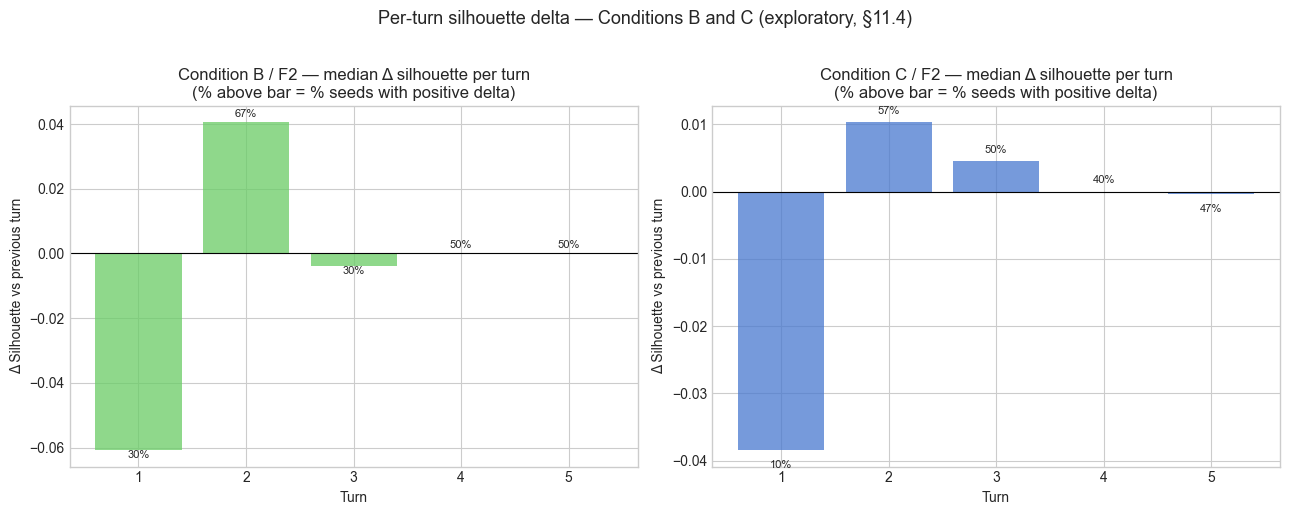

Saved: runs/fig_delta_per_turn.png

                median  pct_positive
condition turn                      
B         1    -0.0608       30.0000
          2     0.0406       66.6667
          3    -0.0038       30.0000
          4     0.0002       50.0000
          5     0.0002       50.0000
C         1    -0.0384       10.0000
          2     0.0103       56.6667
          3     0.0045       50.0000
          4     0.0000       40.0000
          5    -0.0003       46.6667


In [14]:
# ── Build baseline lookup: A/F2 silhouette per seed ──────────────────────
baseline_sil = {}
for _, row in df[(df['condition']=='A') & (df['feature_set']=='F2')].iterrows():
    baseline_sil[row['seed']] = row['silhouette_final']

# ── Extract per-turn deltas for B and C (F2) ─────────────────────────────
delta_rows = []
for _, row in df[df['feature_set']=='F2'].iterrows():
    turns = row.get('turns', [])
    if not isinstance(turns, list) or not turns:
        continue
    seed = row['seed']
    cond = row['condition']
    if cond not in ('B','C') or seed not in baseline_sil:
        continue
    prev_sil = baseline_sil[seed]
    for t in turns:
        delta = t['silhouette'] - prev_sil
        delta_rows.append({'condition': cond, 'seed': seed,
                           'turn': t['turn'], 'delta_sil': delta,
                           'sil': t['silhouette']})
        prev_sil = t['silhouette']

df_delta = pd.DataFrame(delta_rows)

if df_delta.empty:
    print("Nessun dato per B/C ancora disponibile.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, cond, color in zip(axes, ['B','C'], ['#6ACC65','#4878CF']):
        sub = df_delta[df_delta['condition']==cond]
        if sub.empty:
            ax.text(0.5, 0.5, f'Condition {cond} not yet available',
                    ha='center', va='center', transform=ax.transAxes)
            continue
        median_delta = sub.groupby('turn')['delta_sil'].median()
        pct_positive = sub.groupby('turn')['delta_sil'].apply(lambda x: (x>0).mean()*100)
        bars = ax.bar(median_delta.index, median_delta.values, color=color, alpha=0.75)
        ax.axhline(0, color='black', linewidth=0.8)
        for bar, pct in zip(bars, pct_positive):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.001 if bar.get_height() >= 0 else bar.get_height() - 0.003,
                    f'{pct:.0f}%', ha='center', va='bottom', fontsize=8)
        ax.set_title(f'Condition {cond} / F2 — median Δ silhouette per turn\n(% above bar = % seeds with positive delta)')
        ax.set_xlabel('Turn')
        ax.set_ylabel('Δ Silhouette vs previous turn')
        ax.set_xticks(range(1, 6))
    plt.suptitle('Per-turn silhouette delta — Conditions B and C (exploratory, §11.4)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('../runs/fig_delta_per_turn.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: runs/fig_delta_per_turn.png')
    print()
    print(df_delta.groupby(['condition','turn'])['delta_sil']
          .agg(median='median', pct_positive=lambda x: (x>0).mean()*100)
          .round(4).to_string())

### 9.2 Feature weight trajectory per turn (§11.2)

For each run in B and C (F2), extract the `parsed_params` dict at each turn.  
Median weight per feature per turn across all seeds — shows the "clustering strategy" of each condition.

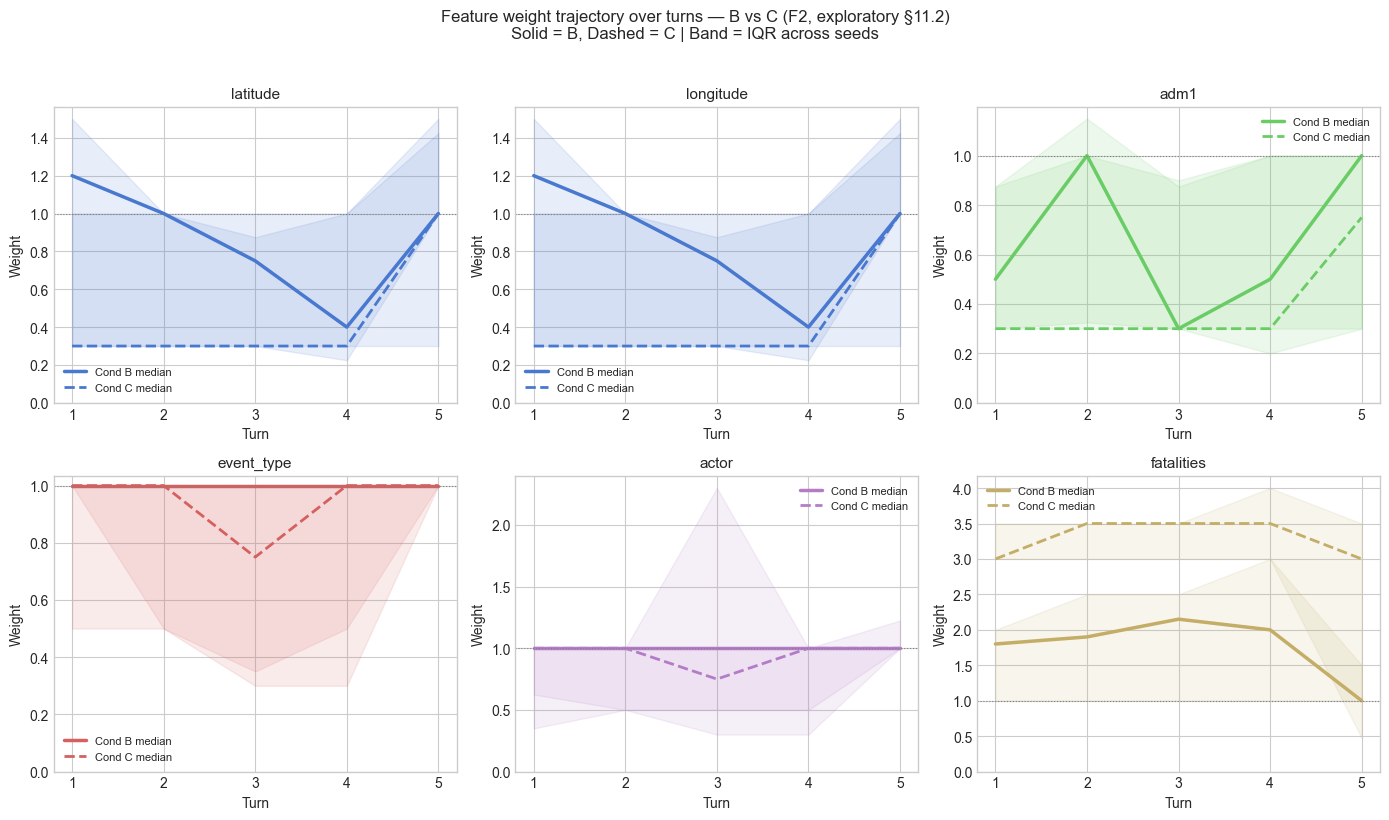

Saved: runs/fig_weight_trajectory.png


In [15]:
FEATURE_GROUPS = ['latitude', 'longitude', 'adm1', 'event_type', 'actor', 'fatalities']
COLORS_FG = ['#4878CF','#4878CF','#6ACC65','#D65F5F','#B47CC7','#C4AD66']

weight_rows = []
for _, row in df[df['feature_set']=='F2'].iterrows():
    turns = row.get('turns', [])
    if not isinstance(turns, list) or not turns:
        continue
    if row['condition'] not in ('B','C'):
        continue
    for t in turns:
        params = t.get('parsed_params', {})
        for fg in FEATURE_GROUPS:
            weight_rows.append({'condition': row['condition'], 'seed': row['seed'],
                                'turn': t['turn'], 'feature': fg,
                                'weight': params.get(fg, 1.0)})

df_weights = pd.DataFrame(weight_rows)

if df_weights.empty:
    print("Nessun dato di peso disponibile.")
else:
    conditions_avail = df_weights['condition'].unique()
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    for idx, (fg, color) in enumerate(zip(FEATURE_GROUPS, COLORS_FG)):
        ax = axes[idx]
        for cond, ls, lw in [('B','-',2.5), ('C','--',2.0)]:
            sub = df_weights[(df_weights['feature']==fg) & (df_weights['condition']==cond)]
            if sub.empty:
                continue
            med = sub.groupby('turn')['weight'].median()
            lo  = sub.groupby('turn')['weight'].quantile(0.25)
            hi  = sub.groupby('turn')['weight'].quantile(0.75)
            ax.plot(med.index, med.values, linestyle=ls, linewidth=lw,
                    color=color, label=f'Cond {cond} median')
            ax.fill_between(med.index, lo.values, hi.values,
                            color=color, alpha=0.12)
        ax.axhline(1.0, color='grey', linewidth=0.8, linestyle=':')
        ax.set_title(f'{fg}', fontsize=11)
        ax.set_xlabel('Turn')
        ax.set_ylabel('Weight')
        ax.set_xticks(range(1, 6))
        ax.set_ylim(bottom=0)
        ax.legend(fontsize=8)

    plt.suptitle('Feature weight trajectory over turns — B vs C (F2, exploratory §11.2)\nSolid = B, Dashed = C | Band = IQR across seeds',
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig('../runs/fig_weight_trajectory.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: runs/fig_weight_trajectory.png')

### 9.3 Instruction taxonomy — B vs C (§11.1)

Each instruction is auto-classified into one of five categories based on keyword matching:
- **geographic** — references position, coordinates, oblast, location
- **intensity** — references fatalities, deaths, casualties
- **actor** — references who was involved
- **balance** — requests redistribution of weights across dimensions
- **generic** — no clear dimension targeted

Keyword classifier is imperfect; used as a fast exploratory proxy. Manual review recommended for final report.

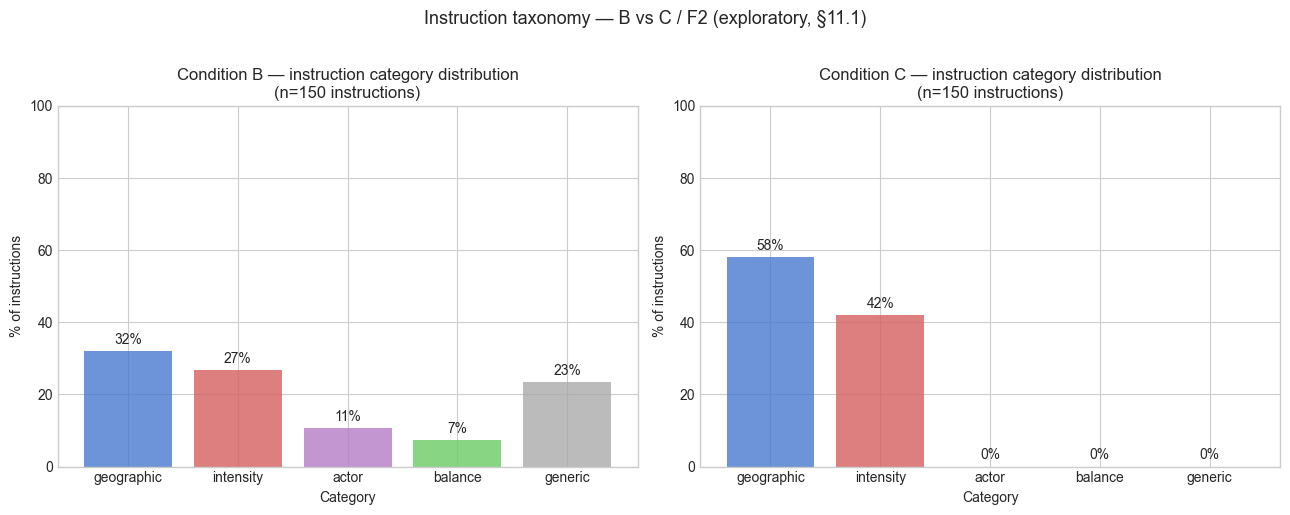

Saved: runs/fig_instruction_taxonomy.png

── Category distribution ──
category   geographic  intensity  actor  balance  generic  TOTAL
condition                                                       
B                  48         40     16       11       35    150
C                  87         63      0        0        0    150


In [16]:
import re

TAXONOMY = {
    'geographic': r'geo|location|position|latitud|longitud|oblast|east|west|north|south|'
                  r'region|area|zone|coordinat|map|spatial|distance|spread|place|where',
    'intensity':  r'fatal|death|deaths|casualt|kill|victim|dead|lethal|high.*kill|'
                  r'low.*fatal|many.*die|most.*death',
    'actor':      r'\bactor\b|\bside\b|force|military|government|troops|who|unit|group|'
                  r'opponent|attacker|defender',
    'balance':    r'balance|equal|weight|mix|combine|reduc.*geo|increas.*fatal|'
                  r'both|all feature|spread.*weight|less.*geo|more.*fatal',
}

def classify_instruction(text):
    text_lower = text.lower()
    for cat, pattern in TAXONOMY.items():
        if re.search(pattern, text_lower):
            return cat
    return 'generic'

# Extract all instructions from B and C (F2)
instr_rows = []
for _, row in df[df['feature_set']=='F2'].iterrows():
    turns = row.get('turns', [])
    if not isinstance(turns, list) or not turns:
        continue
    if row['condition'] not in ('B','C'):
        continue
    for t in turns:
        instr = t.get('instruction','')
        instr_rows.append({
            'condition': row['condition'],
            'seed':      row['seed'],
            'turn':      t['turn'],
            'instruction': instr,
            'category':  classify_instruction(instr),
        })

df_instr = pd.DataFrame(instr_rows)

if df_instr.empty:
    print("Nessuna istruzione disponibile.")
else:
    cats = ['geographic','intensity','actor','balance','generic']
    cat_colors = ['#4878CF','#D65F5F','#B47CC7','#6ACC65','#aaaaaa']

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, cond in zip(axes, ['B','C']):
        sub = df_instr[df_instr['condition']==cond]
        if sub.empty:
            ax.text(0.5,0.5,f'Condition {cond} not available',ha='center',va='center',transform=ax.transAxes)
            continue
        dist = sub['category'].value_counts().reindex(cats, fill_value=0)
        pct  = dist / dist.sum() * 100
        bars = ax.bar(pct.index, pct.values,
                      color=[cat_colors[cats.index(c)] for c in pct.index], alpha=0.8)
        ax.bar_label(bars, labels=[f'{v:.0f}%' for v in pct.values], padding=3)
        ax.set_title(f'Condition {cond} — instruction category distribution\n(n={len(sub)} instructions)')
        ax.set_ylabel('% of instructions')
        ax.set_ylim(0, 100)
        ax.set_xlabel('Category')

    plt.suptitle('Instruction taxonomy — B vs C / F2 (exploratory, §11.1)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('../runs/fig_instruction_taxonomy.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: runs/fig_instruction_taxonomy.png')
    print()
    print('── Category distribution ──')
    pivot = df_instr.groupby(['condition','category']).size().unstack(fill_value=0).reindex(columns=cats, fill_value=0)
    pivot['TOTAL'] = pivot.sum(axis=1)
    print(pivot.to_string())

### 9.4 Instruction-weight alignment check (§11.3)

For each instruction, check whether the feature group that changed most in `parsed_params`
is consistent with the instruction category (as classified in §9.3).

- **aligned**: the largest weight change is in the feature group targeted by the instruction
- **partially aligned**: a related group changed but not the primary one
- **misaligned**: the largest weight change is in an unrelated group

*Semi-automated: alignment judgment uses the category → expected feature mapping below.*

In [17]:
# Mapping: instruction category -> which feature groups are expected to change
EXPECTED_FEATURES = {
    'geographic': {'latitude', 'longitude', 'adm1'},
    'intensity':  {'fatalities'},
    'actor':      {'actor', 'event_type'},
    'balance':    {'latitude', 'longitude', 'adm1', 'fatalities'},  # any change is expected
    'generic':    set(),  # no expectation
}

DEFAULT_WEIGHTS = {fg: 1.0 for fg in FEATURE_GROUPS}

align_rows = []
for _, row in df[df['feature_set']=='F2'].iterrows():
    turns = row.get('turns', [])
    if not isinstance(turns, list) or not turns:
        continue
    if row['condition'] not in ('B','C'):
        continue
    prev_params = DEFAULT_WEIGHTS.copy()
    for t in turns:
        params  = t.get('parsed_params', {})
        instr   = t.get('instruction', '')
        cat     = classify_instruction(instr)
        # Compute absolute weight change per feature
        changes = {fg: abs(params.get(fg,1.0) - prev_params.get(fg,1.0)) for fg in FEATURE_GROUPS}
        max_change_fg = max(changes, key=changes.get)
        max_change_val = changes[max_change_fg]
        expected = EXPECTED_FEATURES.get(cat, set())
        if max_change_val < 0.05:
            alignment = 'no_change'
        elif cat == 'generic':
            alignment = 'generic'
        elif max_change_fg in expected:
            alignment = 'aligned'
        elif cat == 'balance':
            alignment = 'aligned'  # any change counts
        else:
            alignment = 'misaligned'
        align_rows.append({'condition': row['condition'], 'seed': row['seed'],
                           'turn': t['turn'], 'category': cat,
                           'max_changed_feature': max_change_fg,
                           'max_change': round(max_change_val, 3),
                           'alignment': alignment, 'instruction': instr[:80]})
        prev_params = params

df_align = pd.DataFrame(align_rows)

if df_align.empty:
    print("Nessun dato disponibile.")
else:
    print('── Alignment summary by condition ──')
    summary = (df_align[df_align['alignment'].isin(['aligned','misaligned','no_change'])]
               .groupby(['condition','alignment']).size().unstack(fill_value=0))
    summary['TOTAL'] = summary.sum(axis=1)
    for col in ['aligned','misaligned','no_change']:
        if col in summary.columns:
            summary[f'{col}_%'] = (summary[col] / summary['TOTAL'] * 100).round(1)
    print(summary.to_string())
    print()
    print('── Misaligned instructions (sample) ──')
    mis = df_align[df_align['alignment']=='misaligned'][['condition','seed','turn','category','max_changed_feature','instruction']]
    print(mis.head(10).to_string(index=False))

── Alignment summary by condition ──
alignment  aligned  misaligned  no_change  TOTAL  aligned_%  misaligned_%  no_change_%
condition                                                                             
B               65          48          2    115       56.5          41.7          1.7
C               64          76         10    150       42.7          50.7          6.7

── Misaligned instructions (sample) ──
condition  seed  turn   category max_changed_feature                                                                      instruction
        C     0     1 geographic          fatalities Cluster 5 has much higher fatalities than others and includes unknown locations 
        C     0     2  intensity            latitude Cluster 6 contains only extreme outlier events with massive fatalities — separat
        C     0     4 geographic          fatalities Isolate the extreme outlier events in Cluster 7 and prevent them from defining t
        C     1     1 geographic       

### 9.4b Alignment check -- corrected results after manual review

The automated alignment classifier overestimates misalignment because it flags instructions that *mention* a feature dimension in order to criticise it (e.g. 'geography is dominating -- reduce it') as targeting that dimension. Manual review of all 48 flagged cases corrected the counts.

Review file: `runs/alignment_manual_review.json`

In [18]:
import json
from pathlib import Path
from collections import Counter

review = json.loads(Path('../runs/alignment_manual_review.json').read_text())
counts = Counter(r['judgment'] for r in review)

total = 150
aligned_final   = 65 + counts['CLASSIFIER_ERROR']
true_misaligned = counts['TRUE_MISALIGNED']
partial_ambig   = counts['PARTIAL'] + counts['AMBIGUOUS']
generic         = 35
other           = 2 + counts.get('EXTREME',0) + counts.get('TRUNCATED',0)

print('Alignment check -- corrected results (B/F2, ss11.3)')
print(f'Total instructions: {total}')
print()
print(f'  Aligned (incl. classifier errors reclassified): {aligned_final:3d}  ({aligned_final/total*100:.0f}%)')
print(f'  True misaligned (interpreter did wrong thing):  {true_misaligned:3d}  ({true_misaligned/total*100:.0f}%)')
print(f'  Partial / Ambiguous (multi-dim instruction):    {partial_ambig:3d}  ({partial_ambig/total*100:.0f}%)')
print(f'  Generic (no expectation):                       {generic:3d}  ({generic/total*100:.0f}%)')
print(f'  No change / Extreme / Truncated:                {other:3d}  ({other/total*100:.0f}%)')
print()
print('Key finding: true interpreter misalignment rate ~13%.')
print('Automated classifier over-estimated at 32% due to keyword false positives.')
print()
print('True misaligned cases (n=19):')
for r in review:
    if r['judgment'] == 'TRUE_MISALIGNED':
        print(f"  [{r['run_id']} T{r['turn']}] {r['instruction_summary'][:60]}")
        print(f"    -> {r['note']}")


Alignment check -- corrected results (B/F2, ss11.3)
Total instructions: 150

  Aligned (incl. classifier errors reclassified):  77  (51%)
  True misaligned (interpreter did wrong thing):   19  (13%)
  Partial / Ambiguous (multi-dim instruction):     15  (10%)
  Generic (no expectation):                        35  (23%)
  No change / Extreme / Truncated:                  4  (3%)

Key finding: true interpreter misalignment rate ~13%.
Automated classifier over-estimated at 32% due to keyword false positives.

True misaligned cases (n=19):
  [B_F2_seed003 T2] Add more importance to the actor
    -> Actor richiesto, fatalities cambiato invece
  [B_F2_seed005 T5] Give a little more importance to actor weight
    -> Istruzione semplicissima, latitude cambiata invece
  [B_F2_seed007 T4] Fatalities outliers into clusters, very low vs very high
    -> Actor cambiato di 4.7 invece di fatalities
  [B_F2_seed009 T2] Put remote locations and rare ones in same cluster
    -> Intent geografico, fatali